In [ ]:
!nvidia-smi

Mon Jun  8 10:16:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.4 MB/s eta 0:00:00


In [ ]:
import os
from ultralytics import YOLO
import glob
from IPython.display import Image as IPythonImage, display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install roboflow
from roboflow import Roboflow
from google.colab import userdata
private_key = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=private_key)
project = rf.workspace("entername-2sc0s").project("thermal-substation-components")
version = project.version(2)
dataset = version.download("yolov8")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 54.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Thermal-Substation-Components-2 in yolov8:: 100%|██████████| 4596/4596 [00:01<00:00, 4020.23it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!mkdir -p /content/drive/MyDrive/YOLO_Equipment_project
!cp -r /content/Thermal-Substation-Components-2 /content/drive/MyDrive/YOLO_Equipment_project/Dataset_model1
print('Results backed up to google drive')

Results backed up to google drive


In [ ]:
print(os.listdir('Thermal-Substation-Components-2'))

['test', 'data.yaml', 'train', 'README.roboflow.txt', 'README.dataset.txt', 'valid']


In [ ]:
with open('/content/Thermal-Substation-Components-2/data.yaml','r') as file:
  print(file.read())

names:
- Circuit Breakers
- Disconnectors
- Power Transformers
- Surge Arresters
- Wave Traps
nc: 5
roboflow:
  license: CC BY 4.0
  project: thermal-substation-components
  url: https://universe.roboflow.com/entername-2sc0s/thermal-substation-components/dataset/2
  version: 2
  workspace: entername-2sc0s
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
model= YOLO('yolov8n.pt')
results =model.train(data='/content/Thermal-Substation-Components-2/data.yaml',epochs=30,batch=16,imgsz=640,device=0,plots=True)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Thermal-Substation-Components-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [ ]:
!ls /content/drive/MyDrive/YOLO_Equipment_project/Training_results

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2660.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch2661.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch2662.jpg  weights
labels.jpg			 train_batch2.jpg



image 1/1 /content/drive/MyDrive/YOLO_Equipment_project/test1.jpg: 512x640 2 Surge Arresterss, 188.7ms
Speed: 4.6ms preprocess, 188.7ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/predict-2


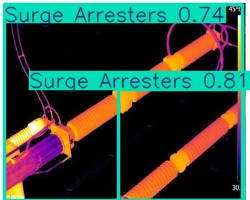

In [ ]:
model= YOLO('/content/drive/MyDrive/YOLO_Equipment_project/Training_results/weights/best.pt')
result = model.predict(source='/content/drive/MyDrive/YOLO_Equipment_project/test1.jpg',conf=0.5,save=True)
latest_predict_folder=max(glob.glob('/content/runs/detect/predict*'))
display(IPythonImage(filename=f"{latest_predict_folder}/test1.jpg"))


image 1/1 /content/drive/MyDrive/YOLO_Equipment_project/test2.jpg: 544x640 3 Disconnectorss, 2 Surge Arresterss, 208.9ms
Speed: 3.6ms preprocess, 208.9ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict-2


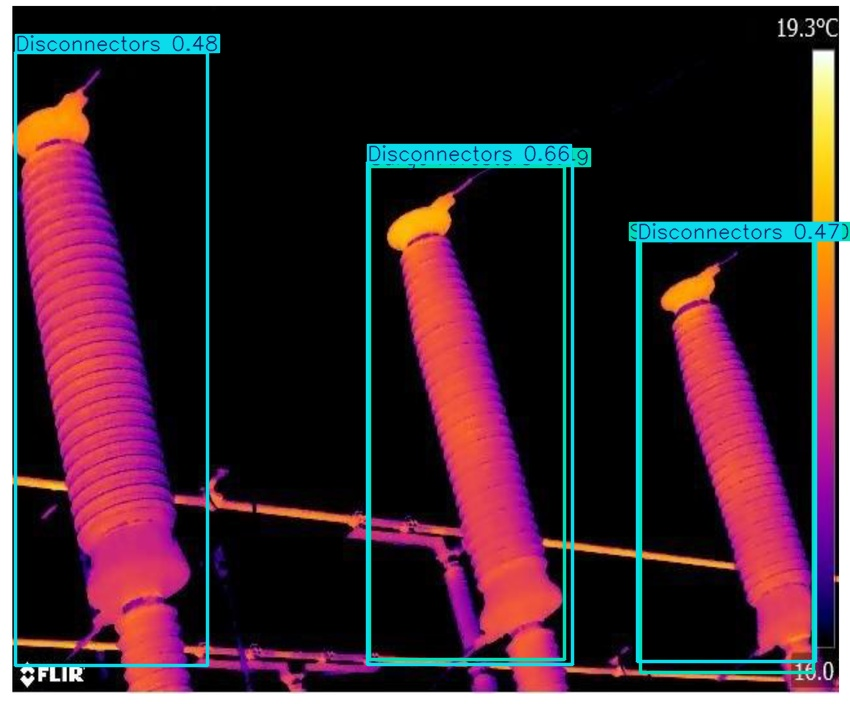

In [ ]:
result = model.predict(source='/content/drive/MyDrive/YOLO_Equipment_project/test2.jpg',conf=0.3,save=True)
latest_predict_folder=max(glob.glob('/content/runs/detect/predict*'))
display(IPythonImage(filename=f"{latest_predict_folder}/test2.jpg"))

In [ ]:
# Evaluating the metrics
model=YOLO('/content/drive/MyDrive/YOLO_Equipment_project/Training_results/weights/best.pt')
metrics = model.val()
print(f"Precision(P) : {metrics.results_dict['metrics/precision(B)']:4f}")
print(f"Recall(R) : {metrics.results_dict['metrics/recall(B)']:4f}")
print(f"mAP50 : {metrics.results_dict['metrics/mAP50(B)']:4f}")
print(f"mAP50-95 : {metrics.results_dict['metrics/mAP50-95(B)']:4f}")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 729.5±288.7 MB/s, size: 37.4 KB)
val: Scanning /content/Thermal-Substation-Components-2/valid/labels... 110 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 519.1it/s 0.2s
val: New cache created: /content/Thermal-Substation-Components-2/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.0s/it 27.7s
                   all        110        267      0.942      0.926      0.964      0.626
      Circuit Breakers         30         84      0.962      0.909      0.959      0.572
         Disconnectors         21         90      0.923      0.929      0.942      0.582
    Power Transformers         21         24      0.933      0.875      0.974      0.693
       Surge Arresters         24    

In [ ]:
!mkdir -p /content/drive/MyDrive/YOLO_Equipment_project/runs
!cp -r /content/runs /content/drive/MyDrive/YOLO_Equipment_project/runs
print('Results backed up to google drive')

Results backed up to google drive


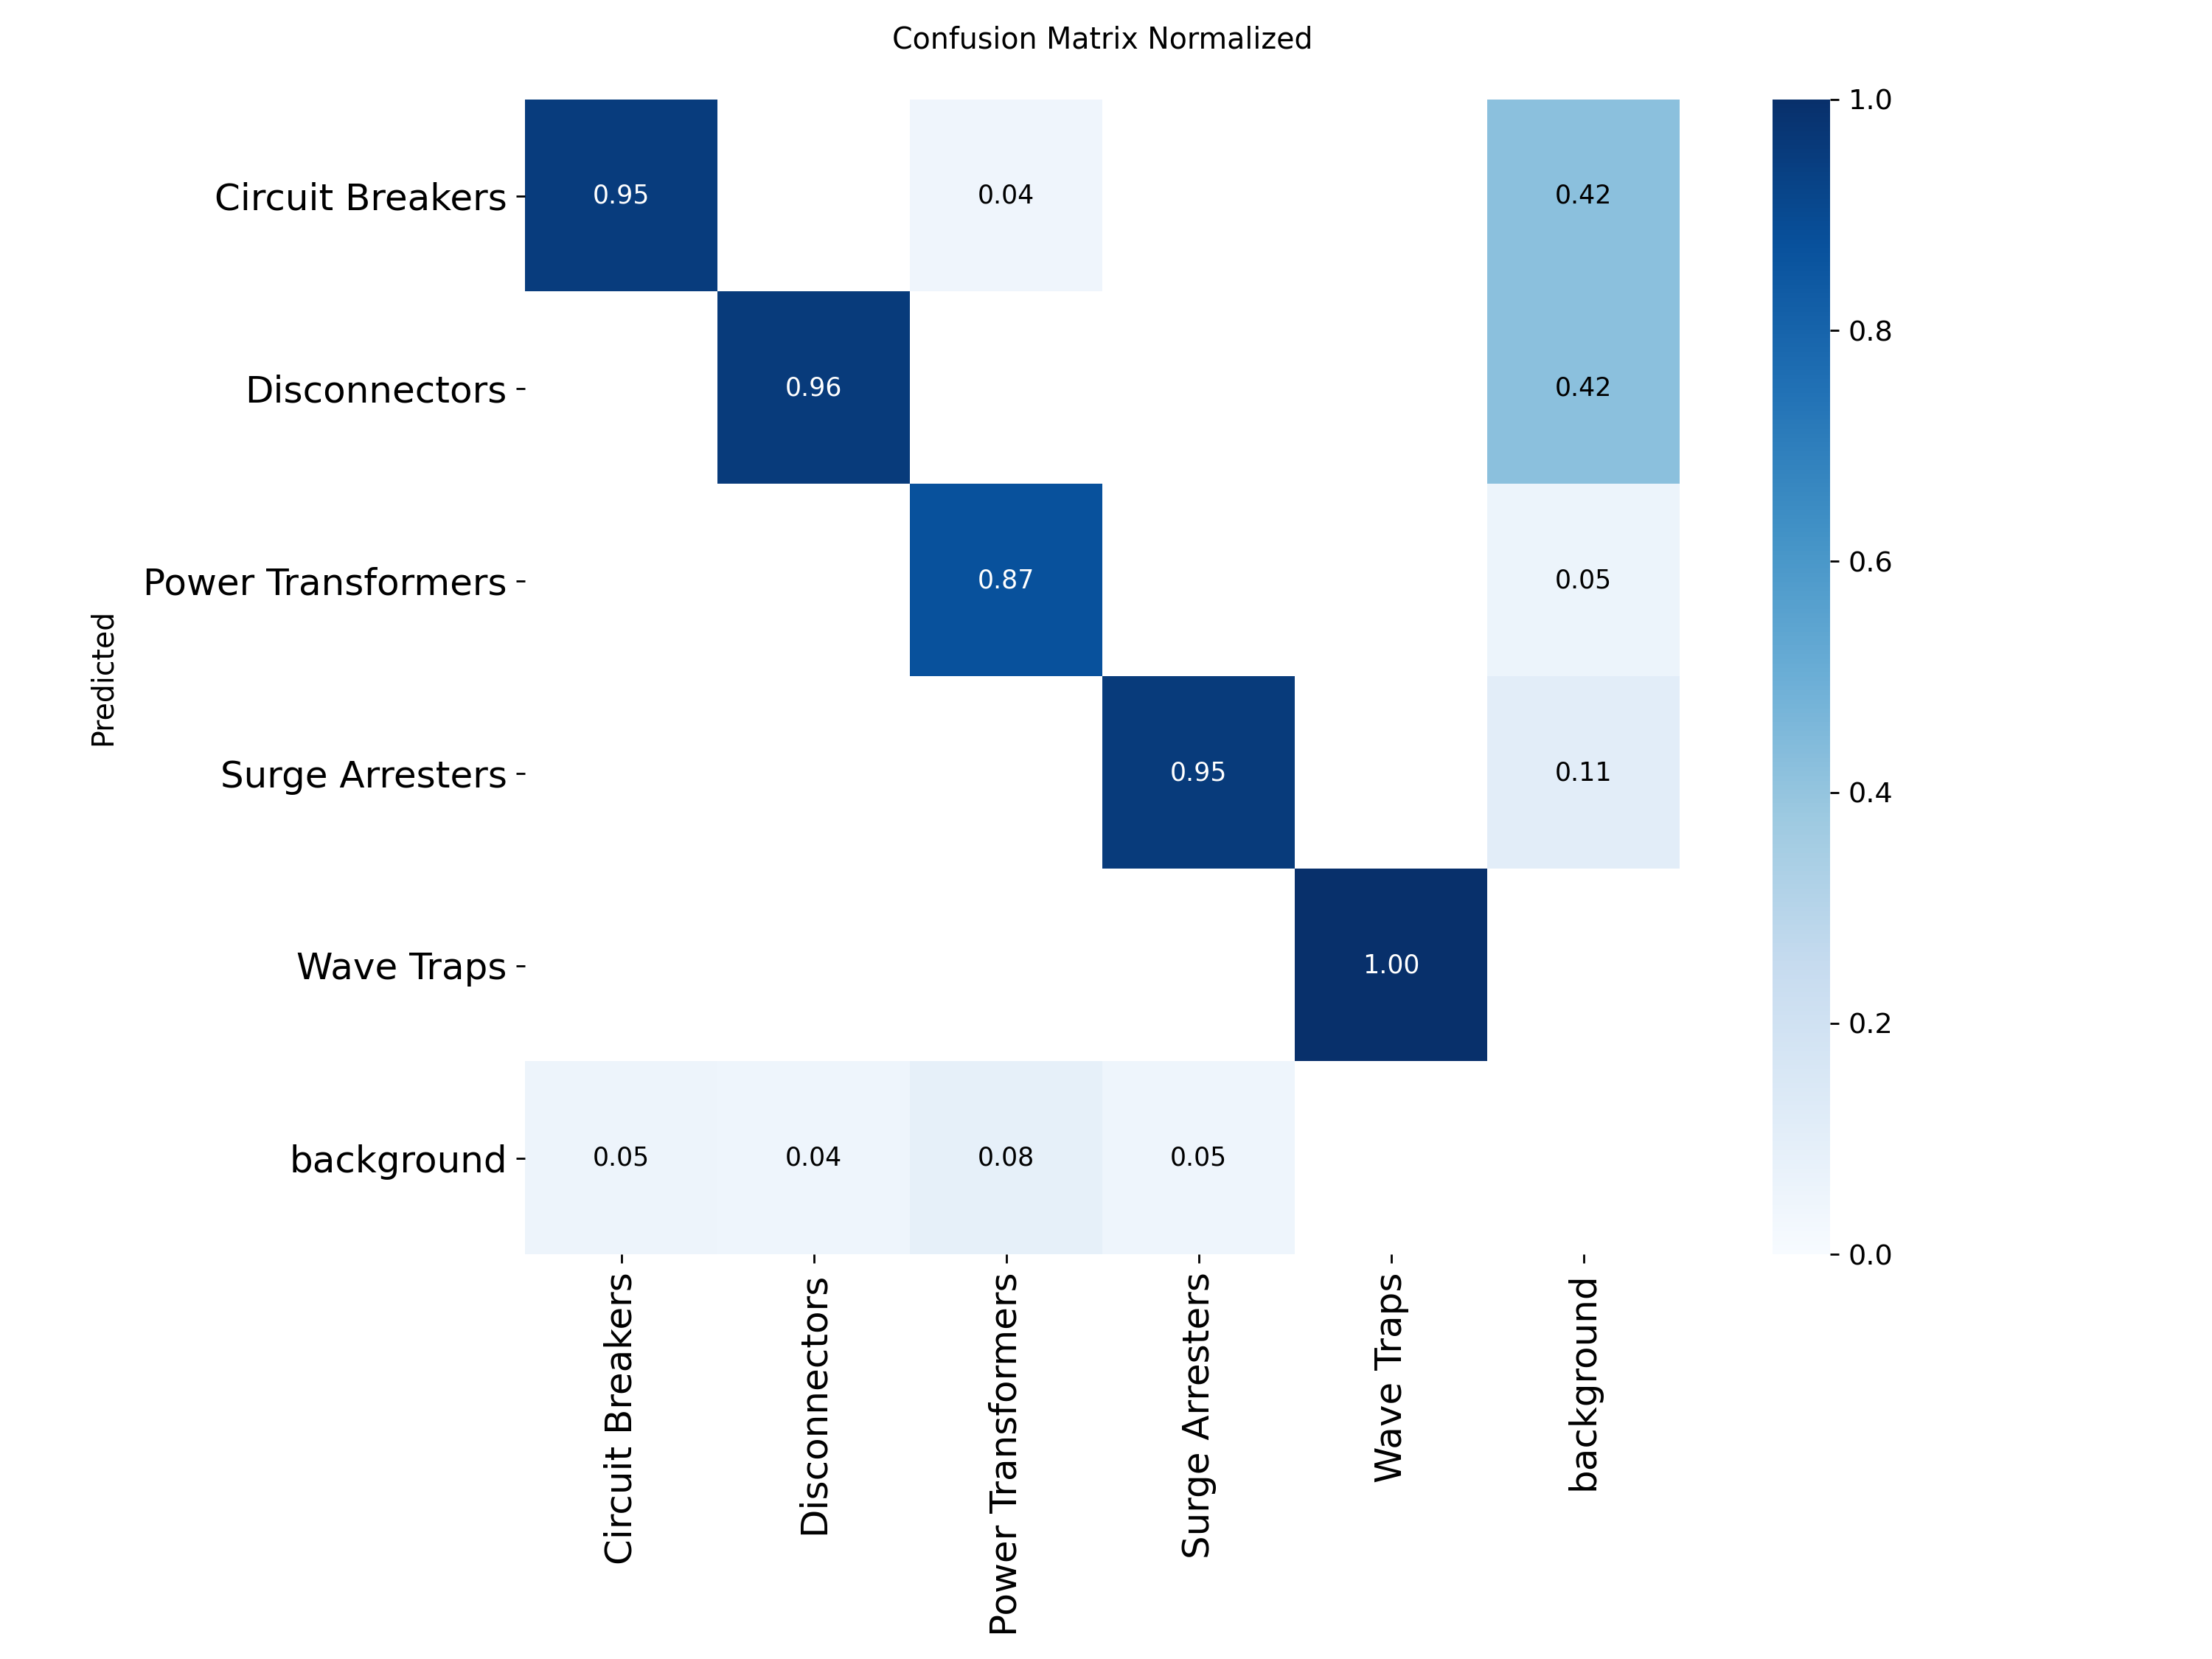

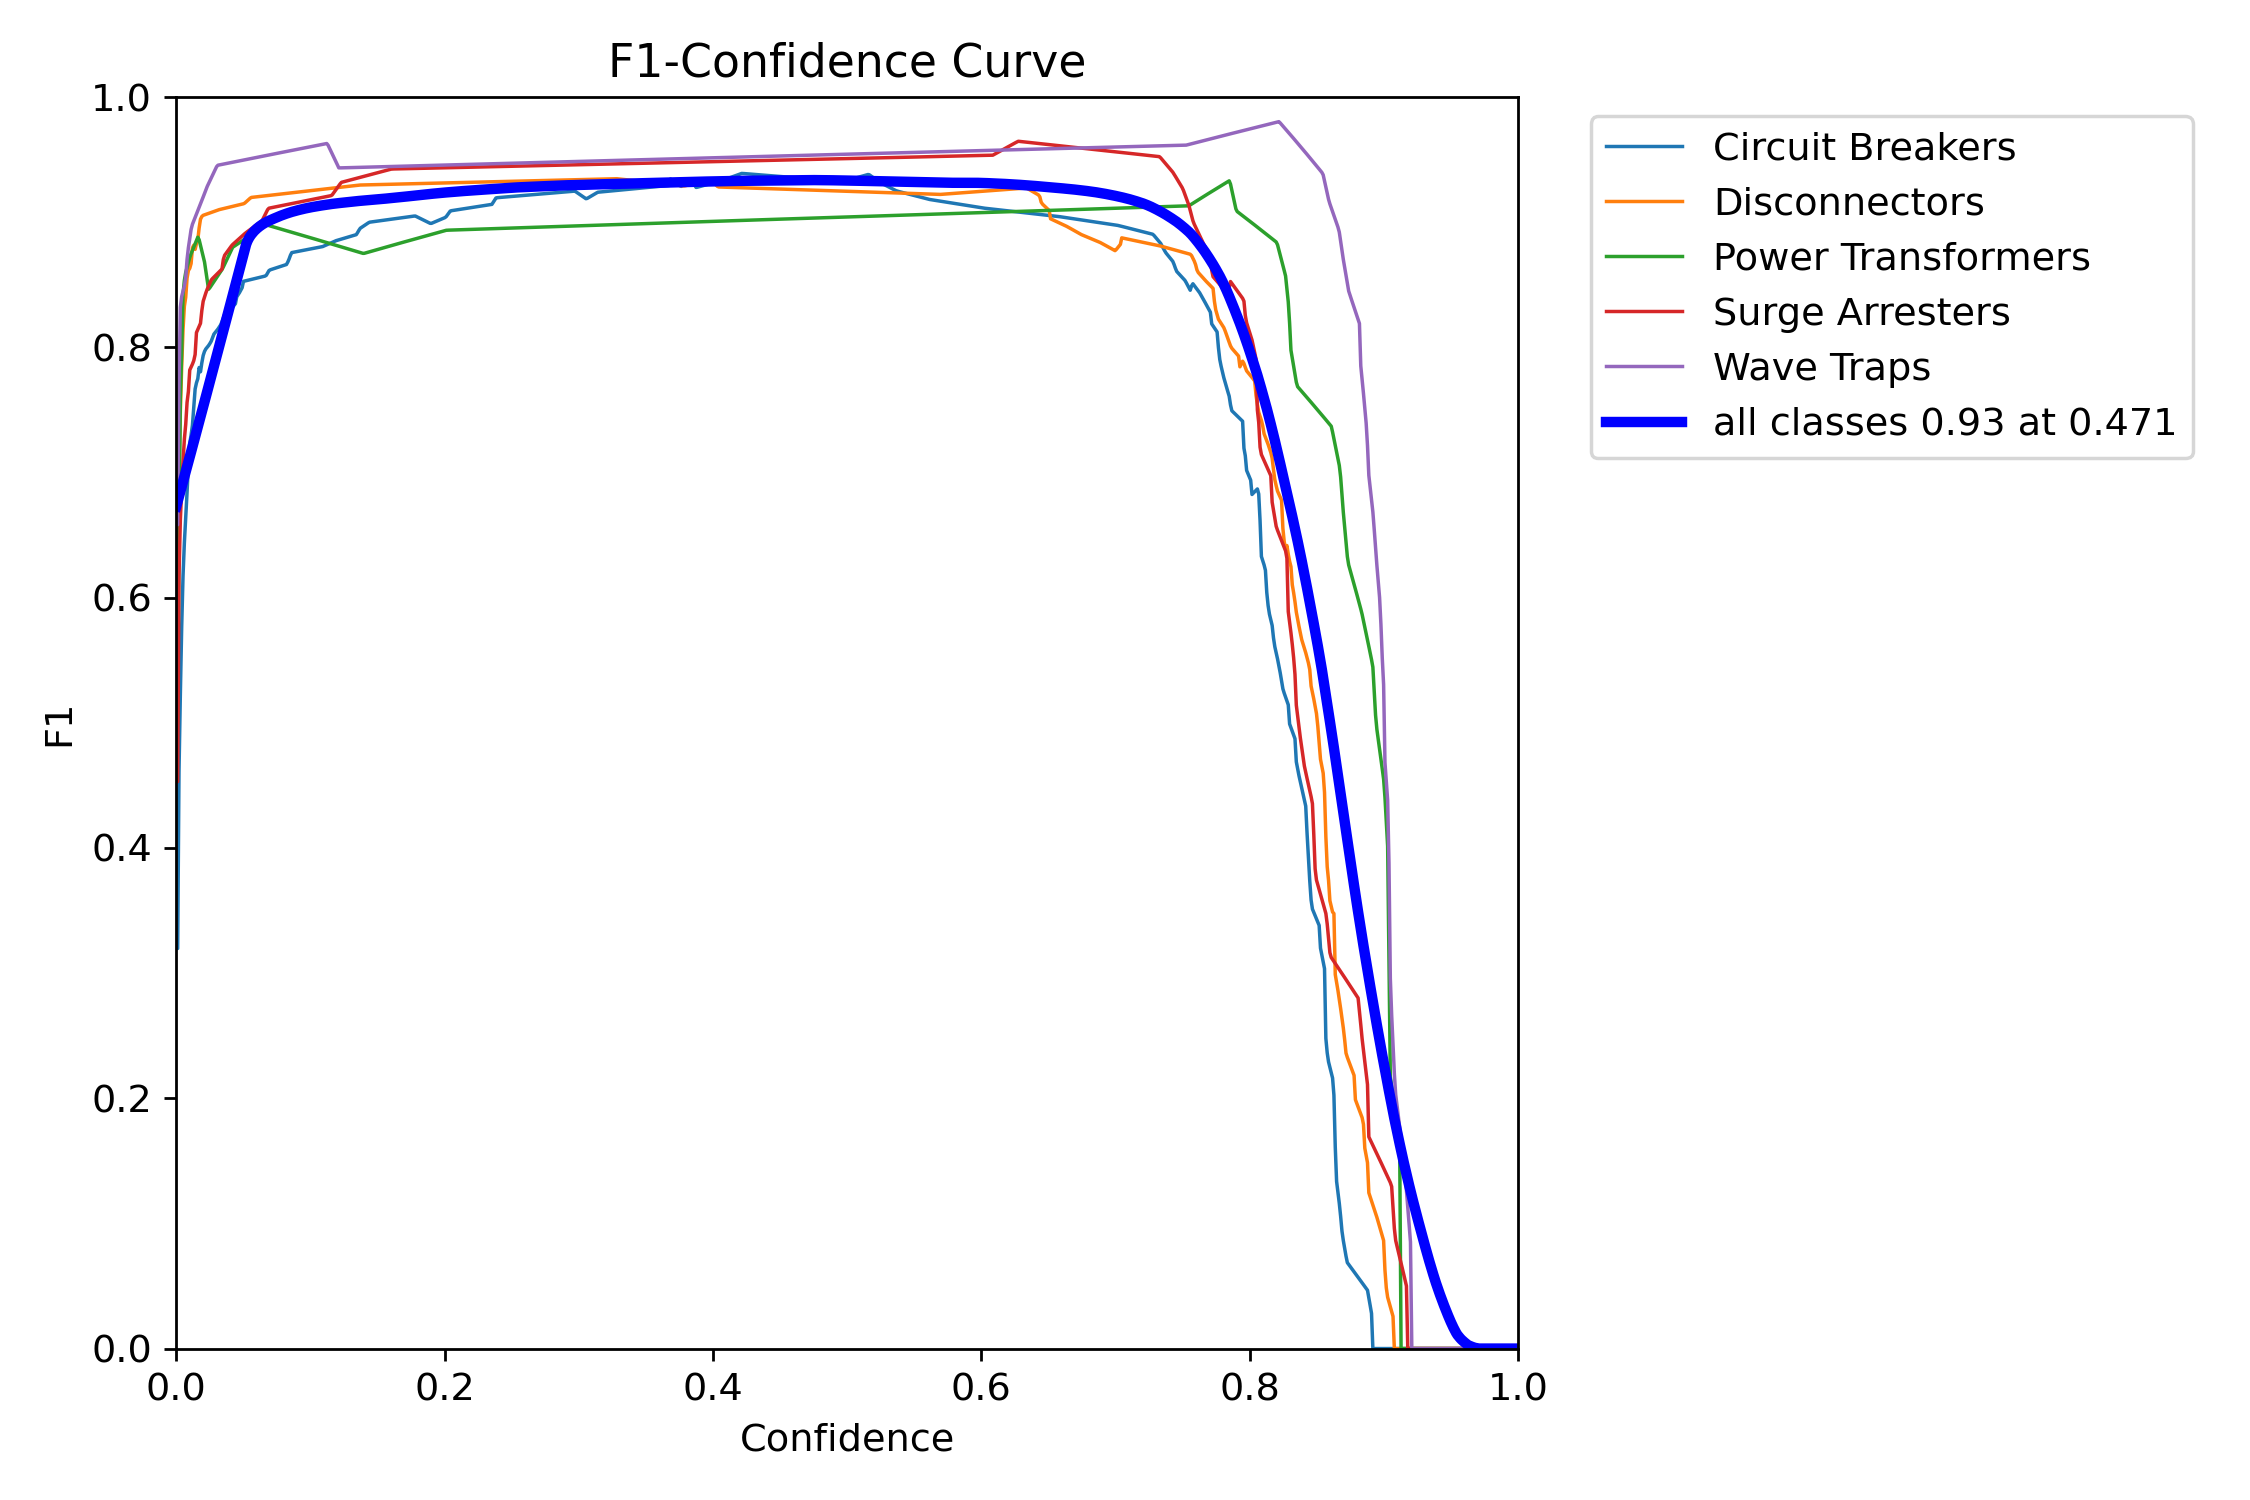

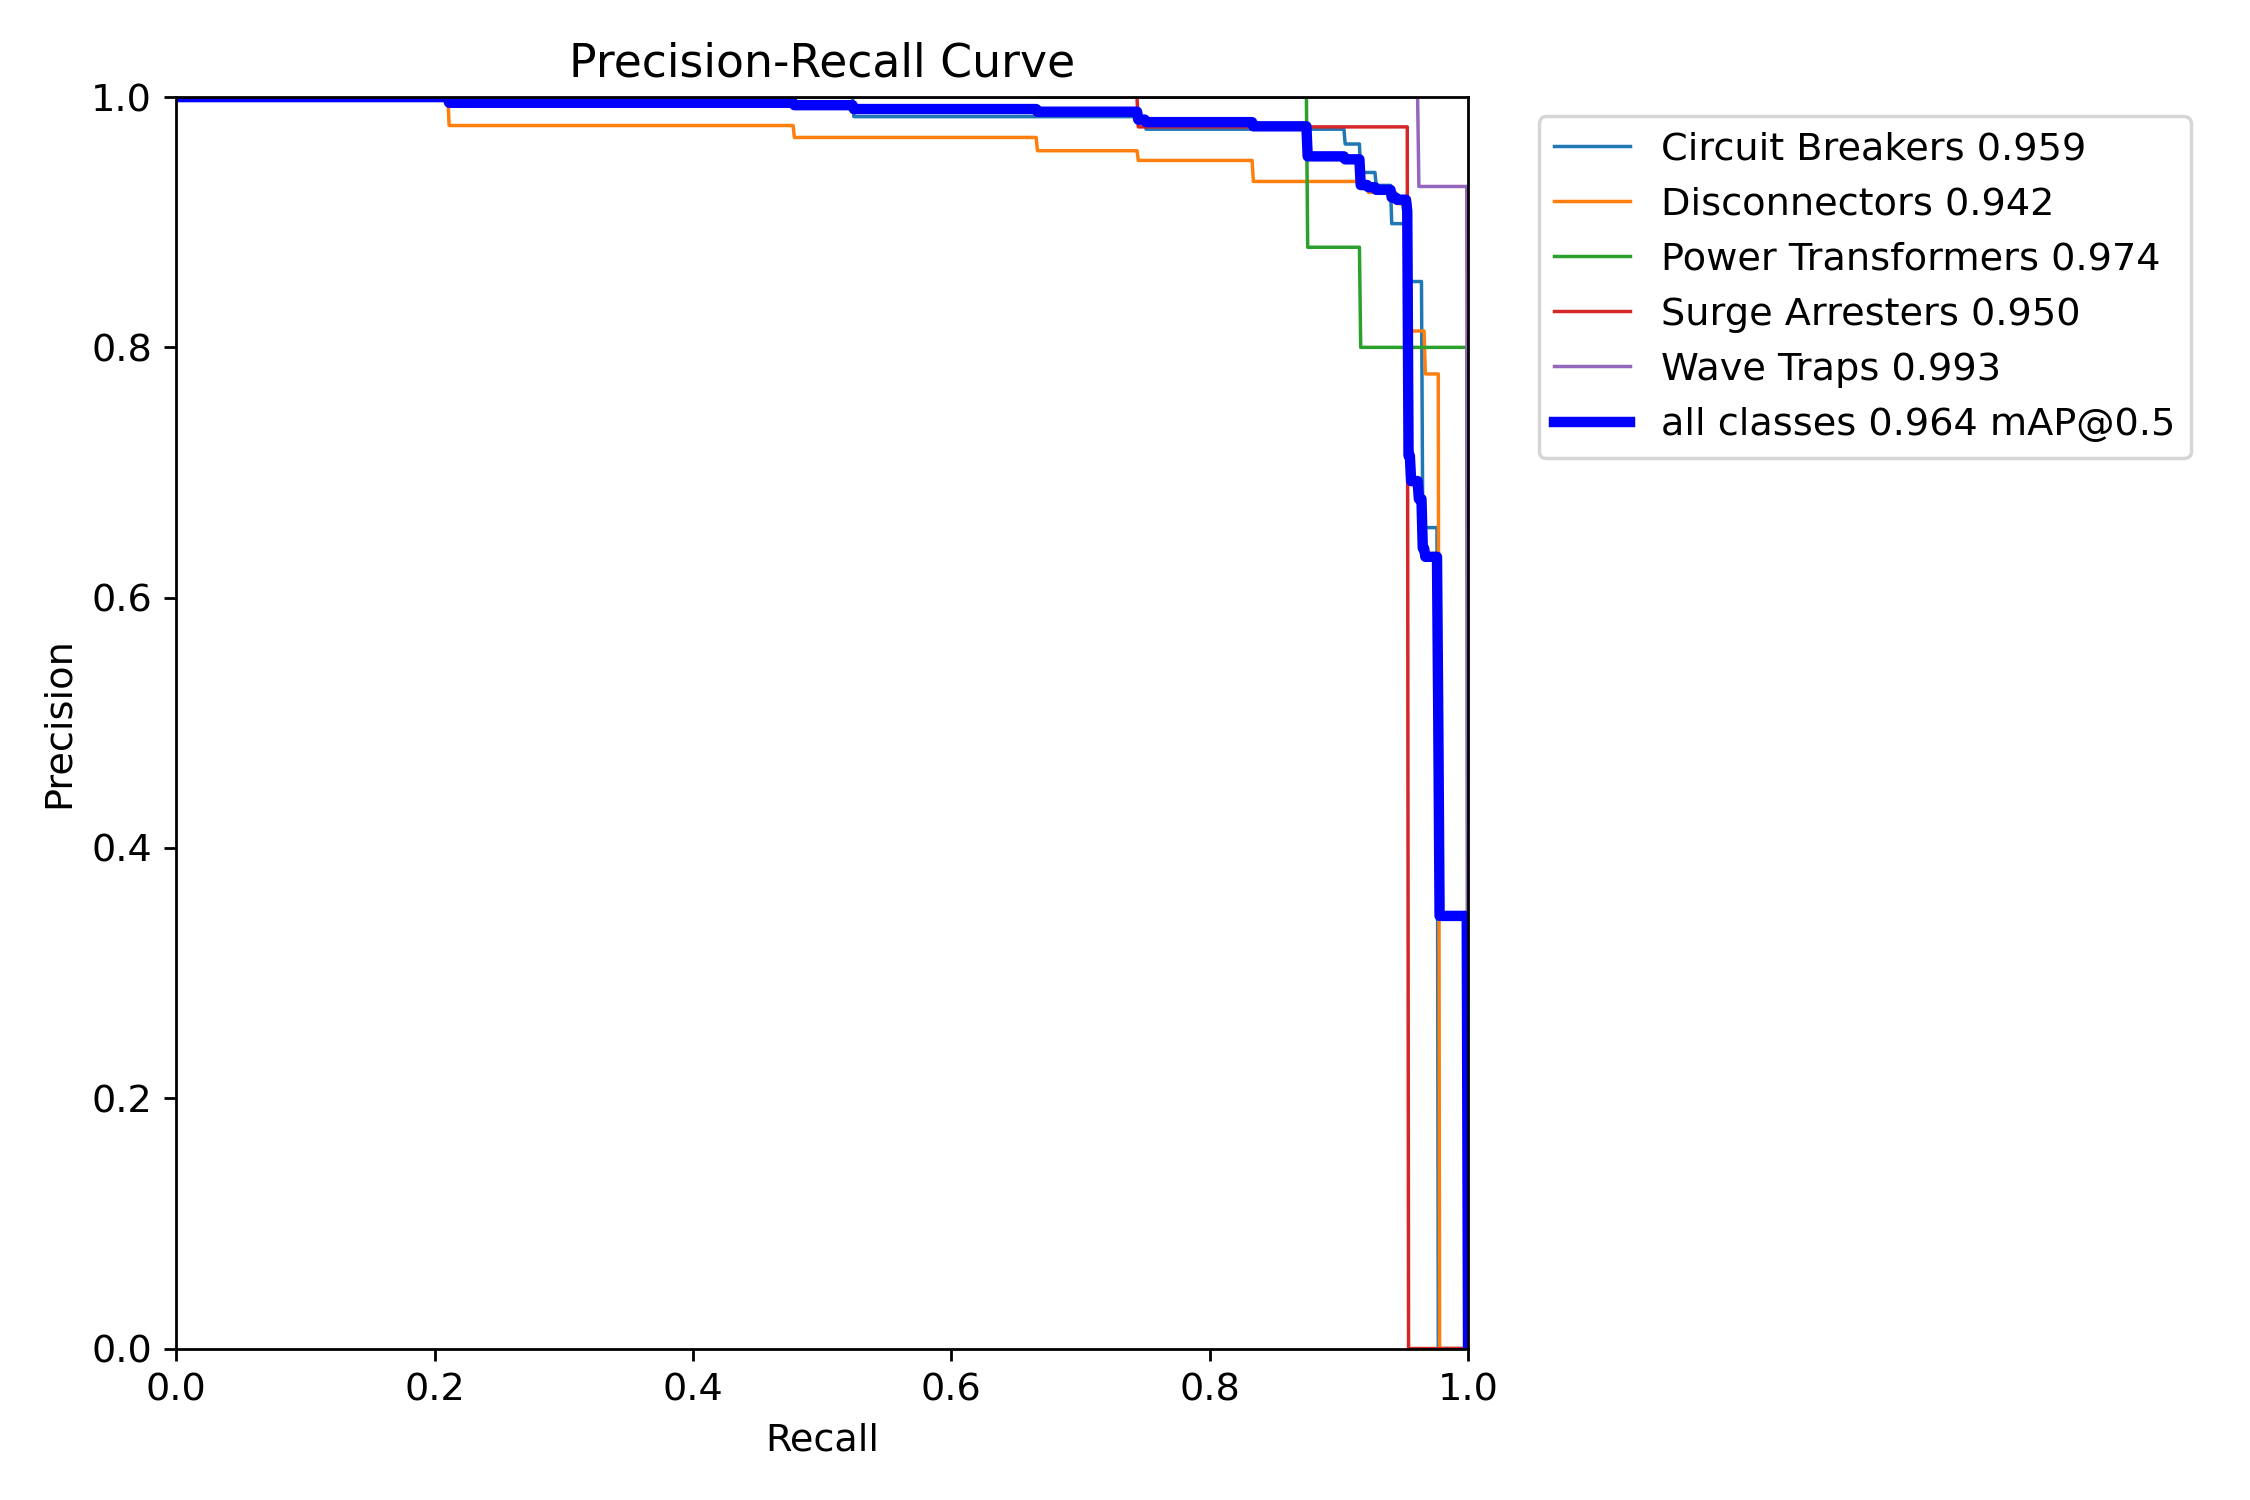

In [ ]:
# Plotting the evaluation charts
latest_val_folder= max(glob.glob('/content/drive/MyDrive/YOLO_Equipment_project/runs/detect/val*'))
charts = ['confusion_matrix_normalized.png','BoxF1_curve.png','BoxPR_curve.png']
for chart_name in charts:
   chart_path = f"{latest_val_folder}/{chart_name}"
   display(IPythonImage(filename = chart_path))


Abalation Study

In [ ]:
model_abalation=YOLO('yolov8s.pt')
results_abalation = model_abalation.train(data='/content/drive/MyDrive/YOLO_Equipment_project/Dataset_model1/data.yaml',epochs=30,batch=16,imgsz=640,device=0,plots=True)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLO_Equipment_project/Dataset_model1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=

Abalation metrics evalution

In [ ]:
from ultralytics import YOLO
model_eval = YOLO('/content/drive/MyDrive/YOLO_Equipment_project/Ablation_results/weights/best.pt')
metrics_ablation = model_eval.val()
print(f"Precision (P) : {metrics_ablation.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall (R) : {metrics_ablation.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50 : {metrics_ablation.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95 : {metrics_ablation.results_dict['metrics/mAP50-95(B)']:.4f}")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 1.2±0.9 ms, read: 0.2±0.1 MB/s, size: 30.5 KB)
val: Scanning /content/drive/MyDrive/YOLO_Equipment_project/Dataset_model1/valid/labels.cache... 110 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 3.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 7.9s/it 55.0s
                   all        110        267      0.952      0.927      0.948      0.618
      Circuit Breakers         30         84      0.946      0.893      0.926      0.538
         Disconnectors         21         90      0.892      0.914      0.925      0.569
    Power Transformers         21         24      0.974      0.875      0.942      0.709
       Surge Arresters         24         43       0.97      0.953       0.95      0.593
            Wave Tra

In [ ]:
!mkdir -p /content/drive/MyDrive/YOLO_Equipment_project/Ablation_results/metrics
!cp -r /content/runs /content/drive/MyDrive/YOLO_Equipment_project/Ablation_results/metrics

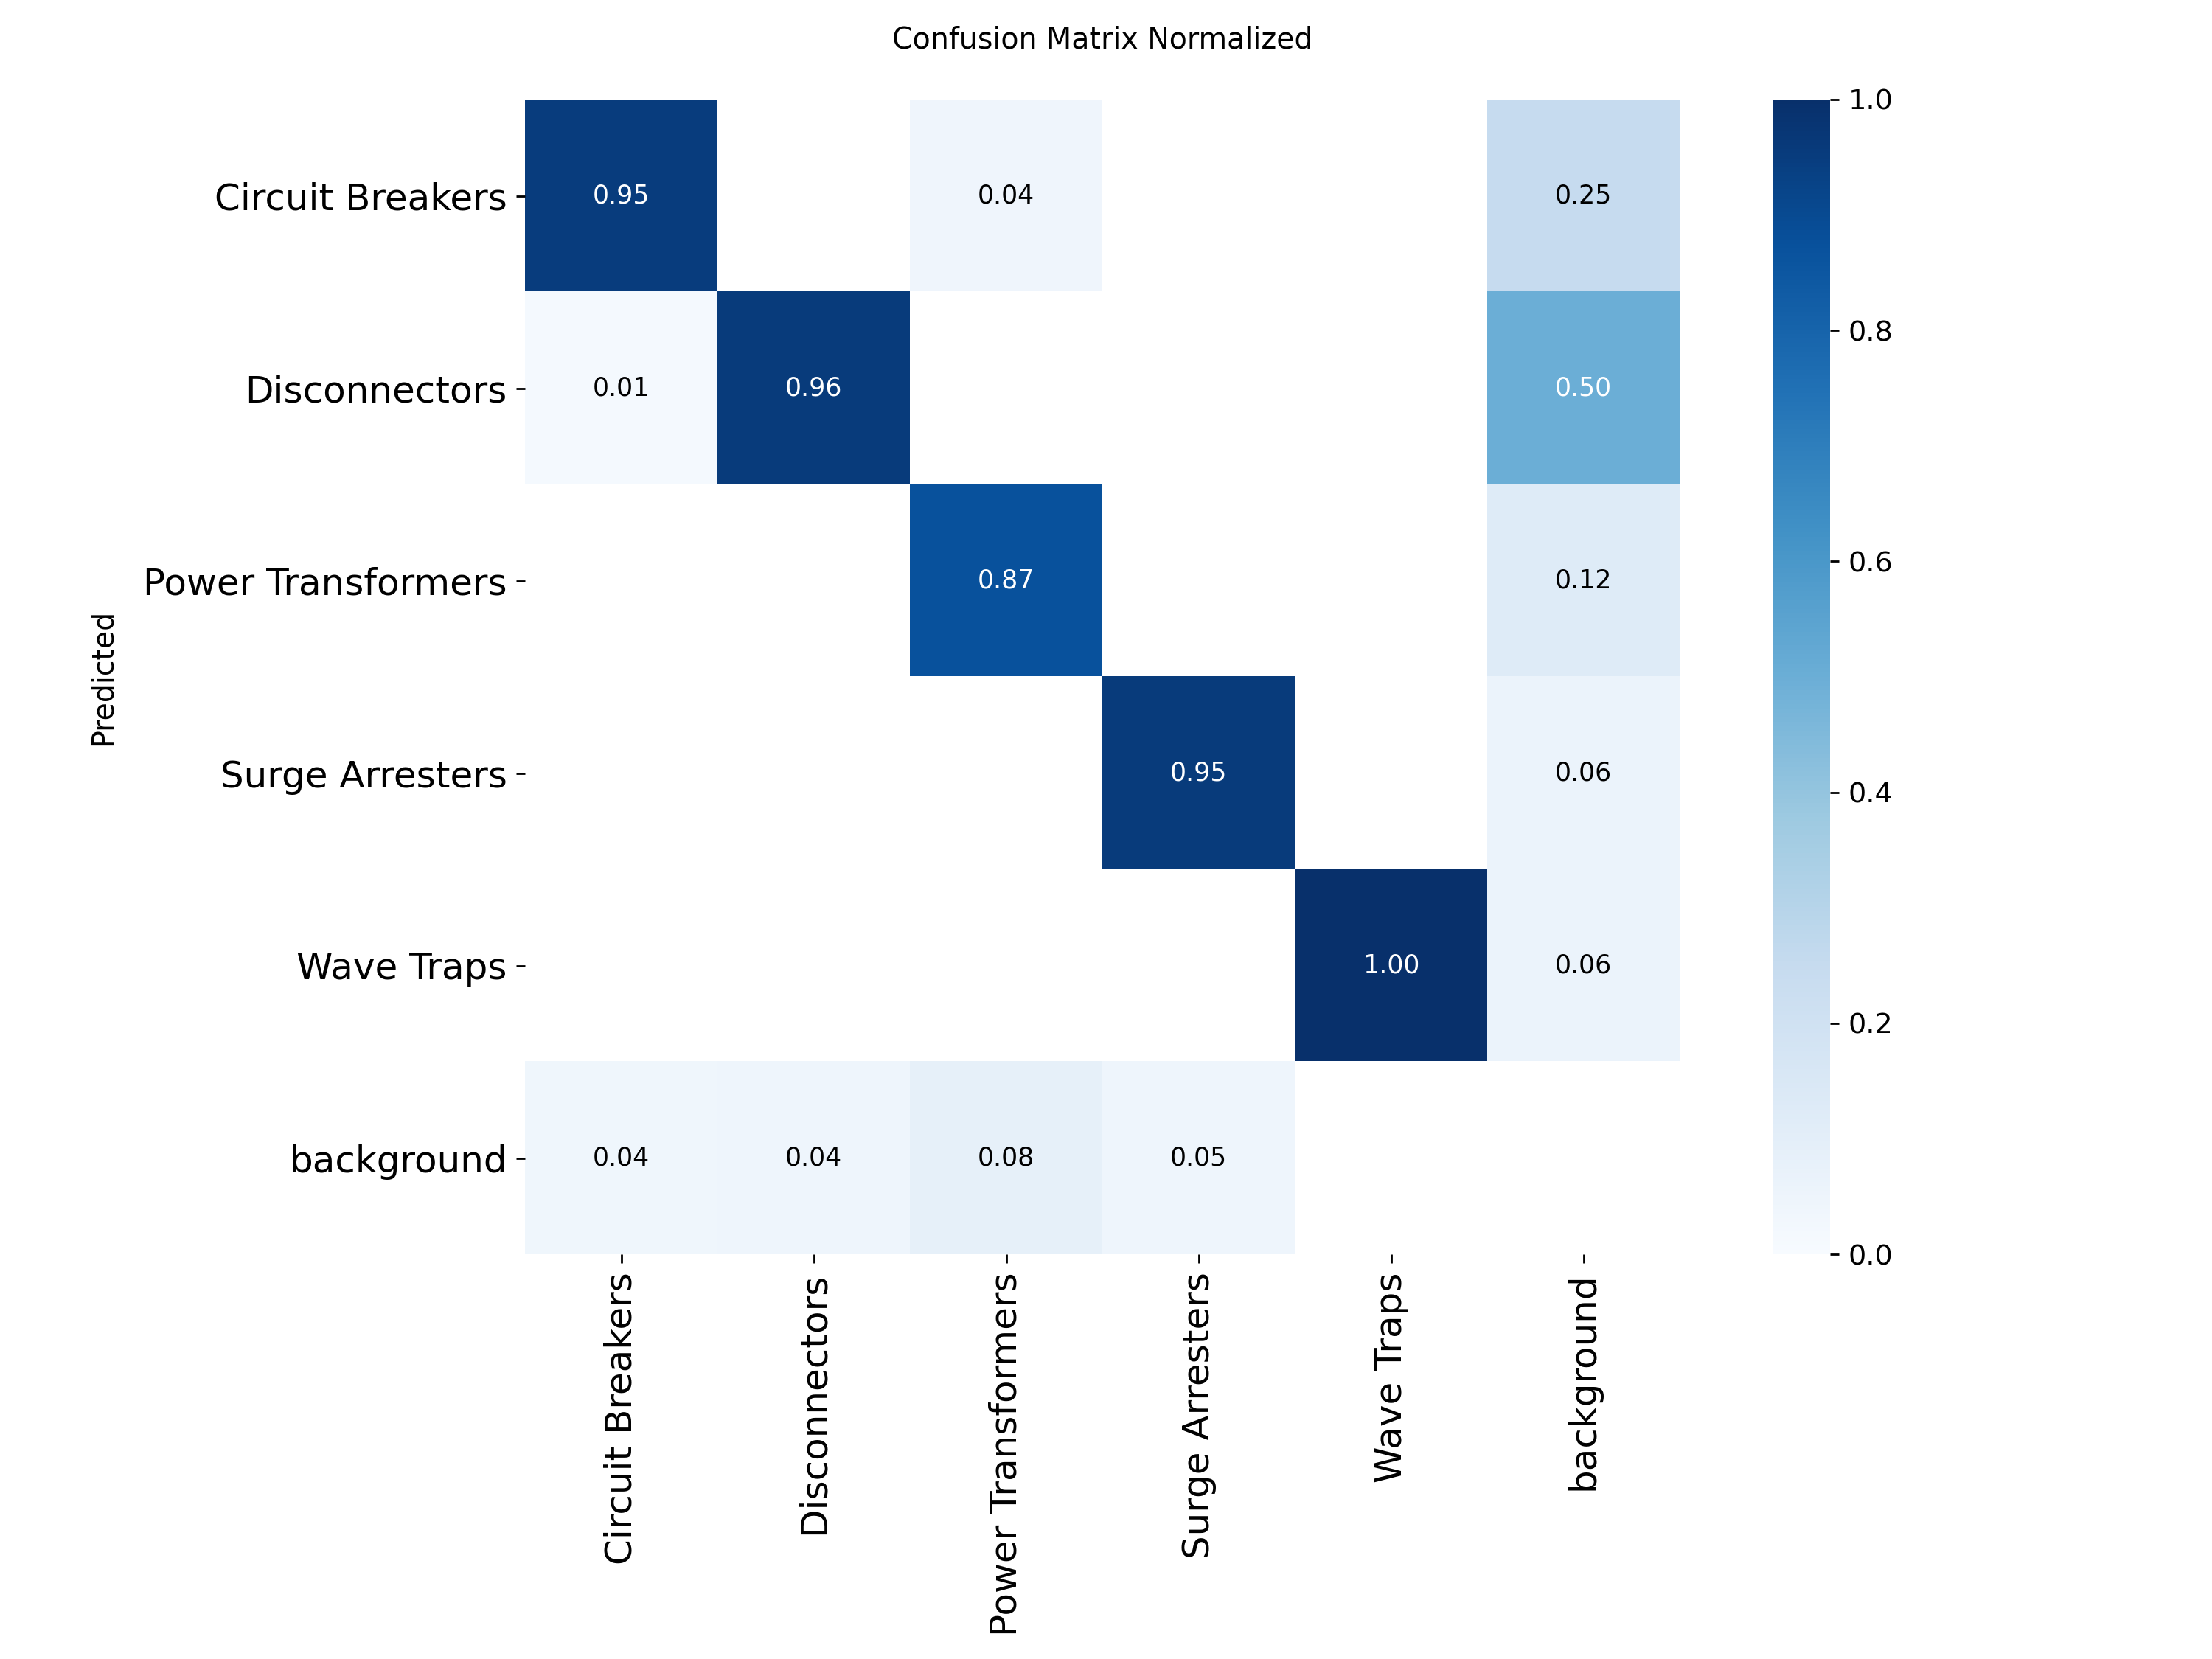

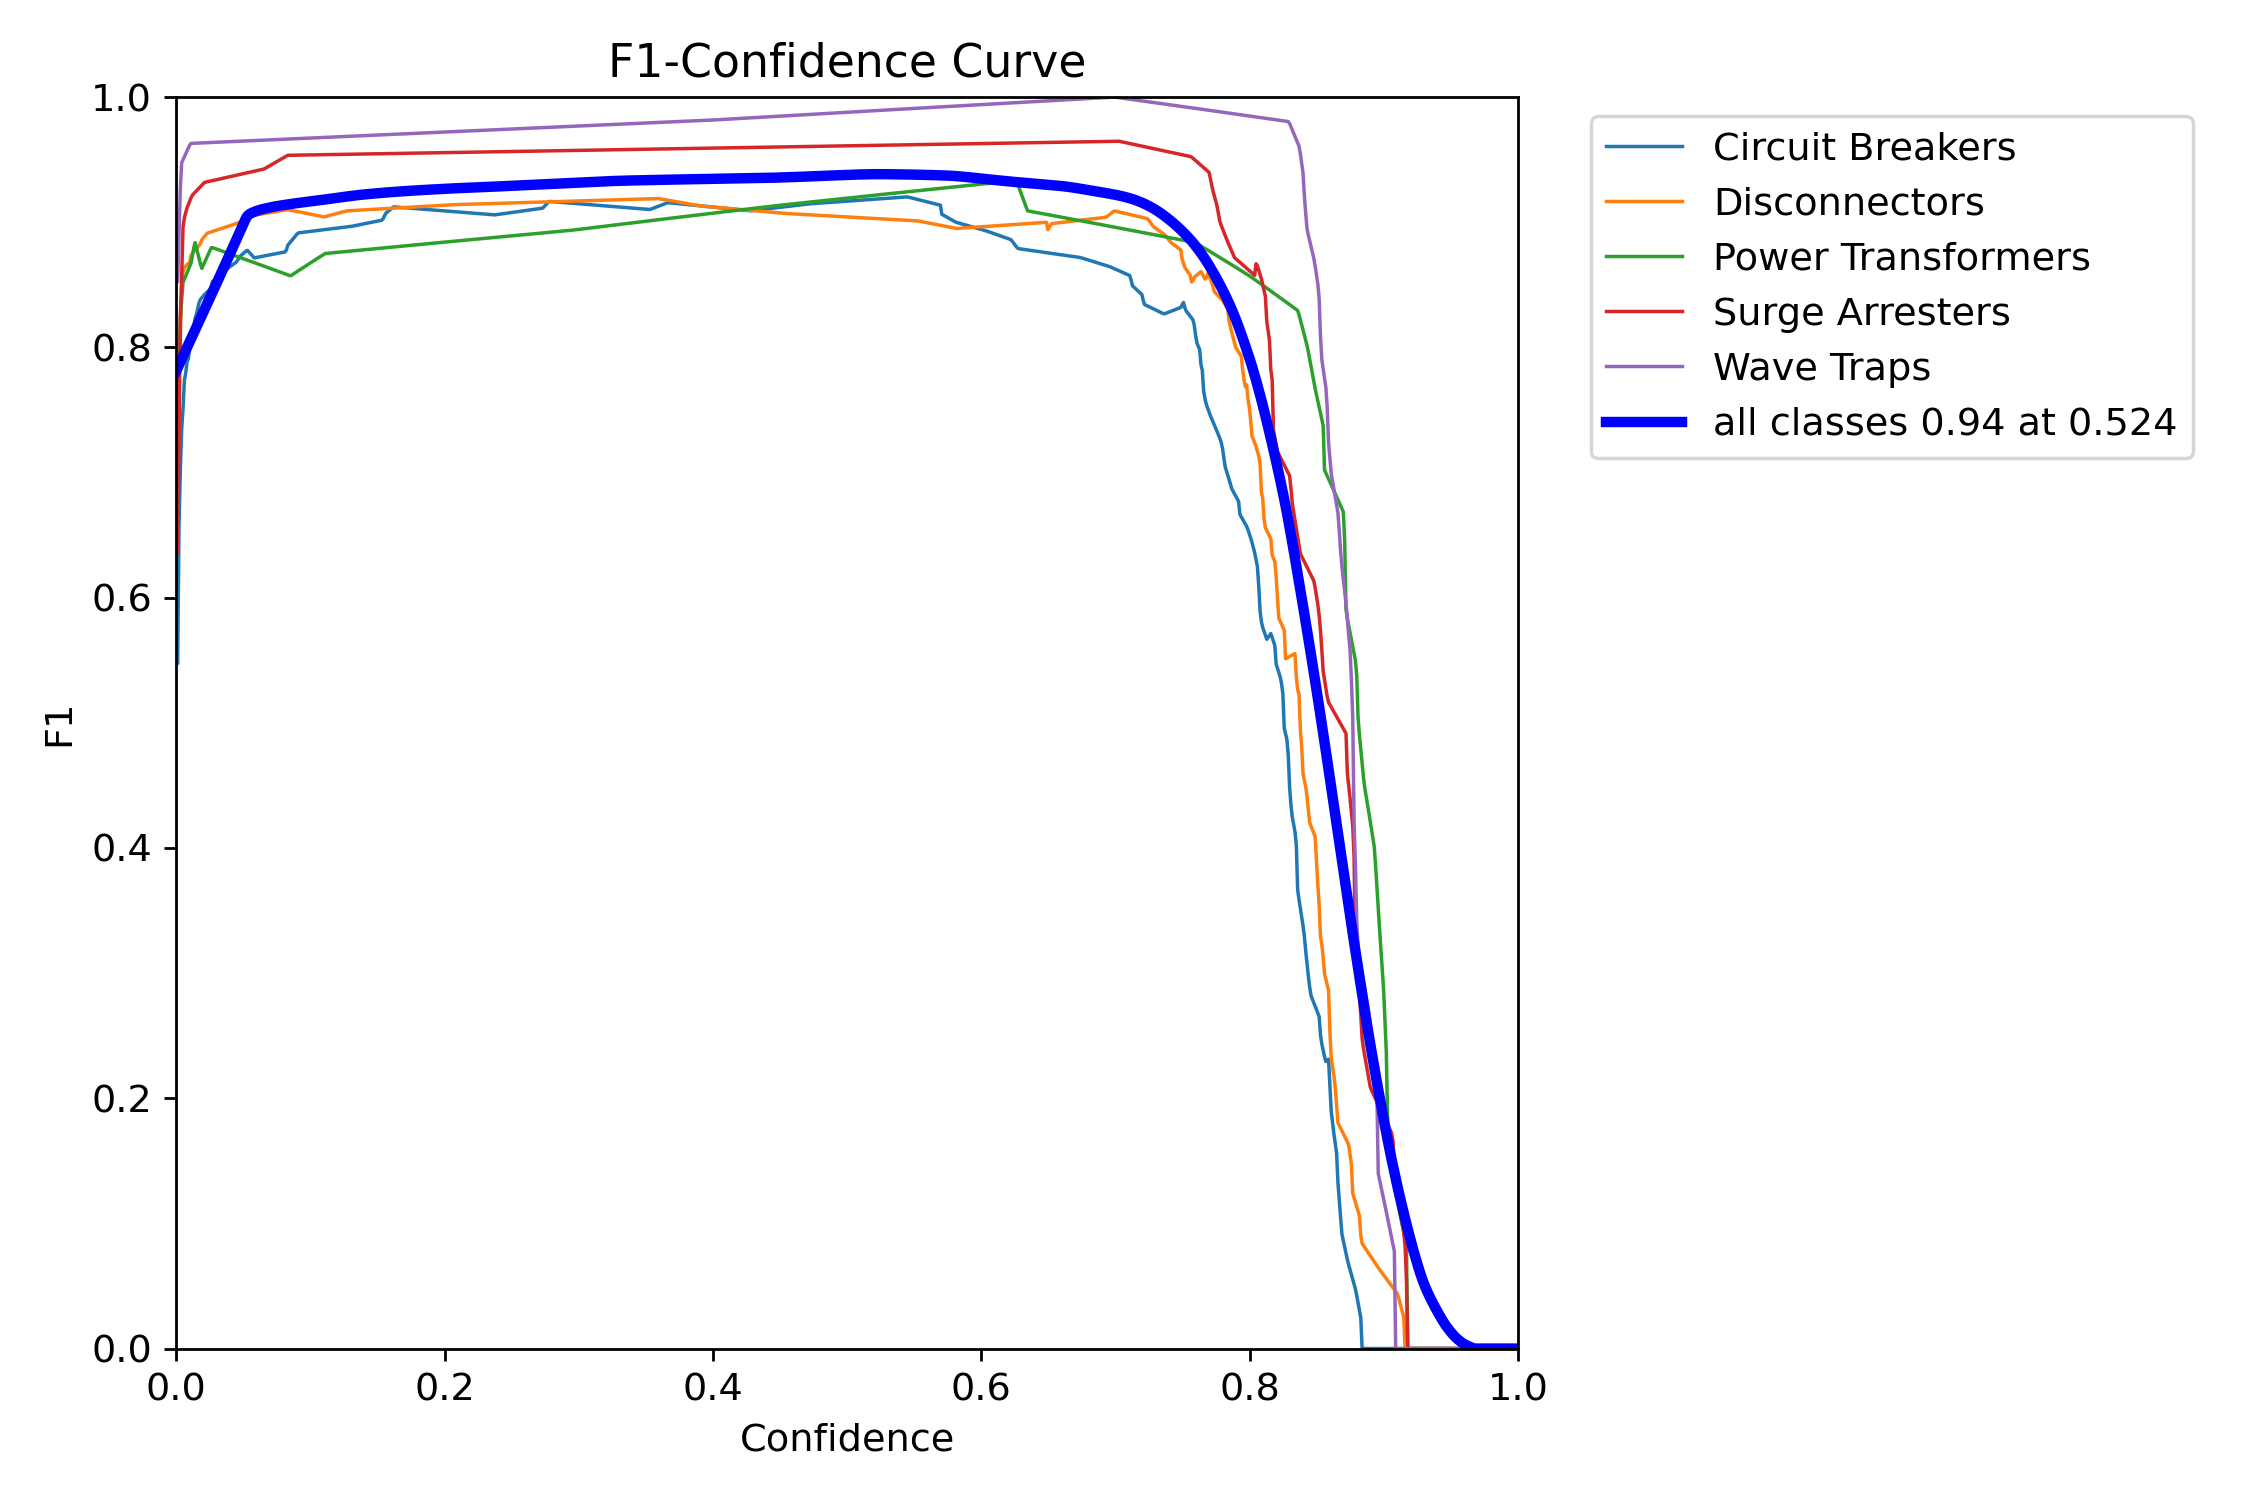

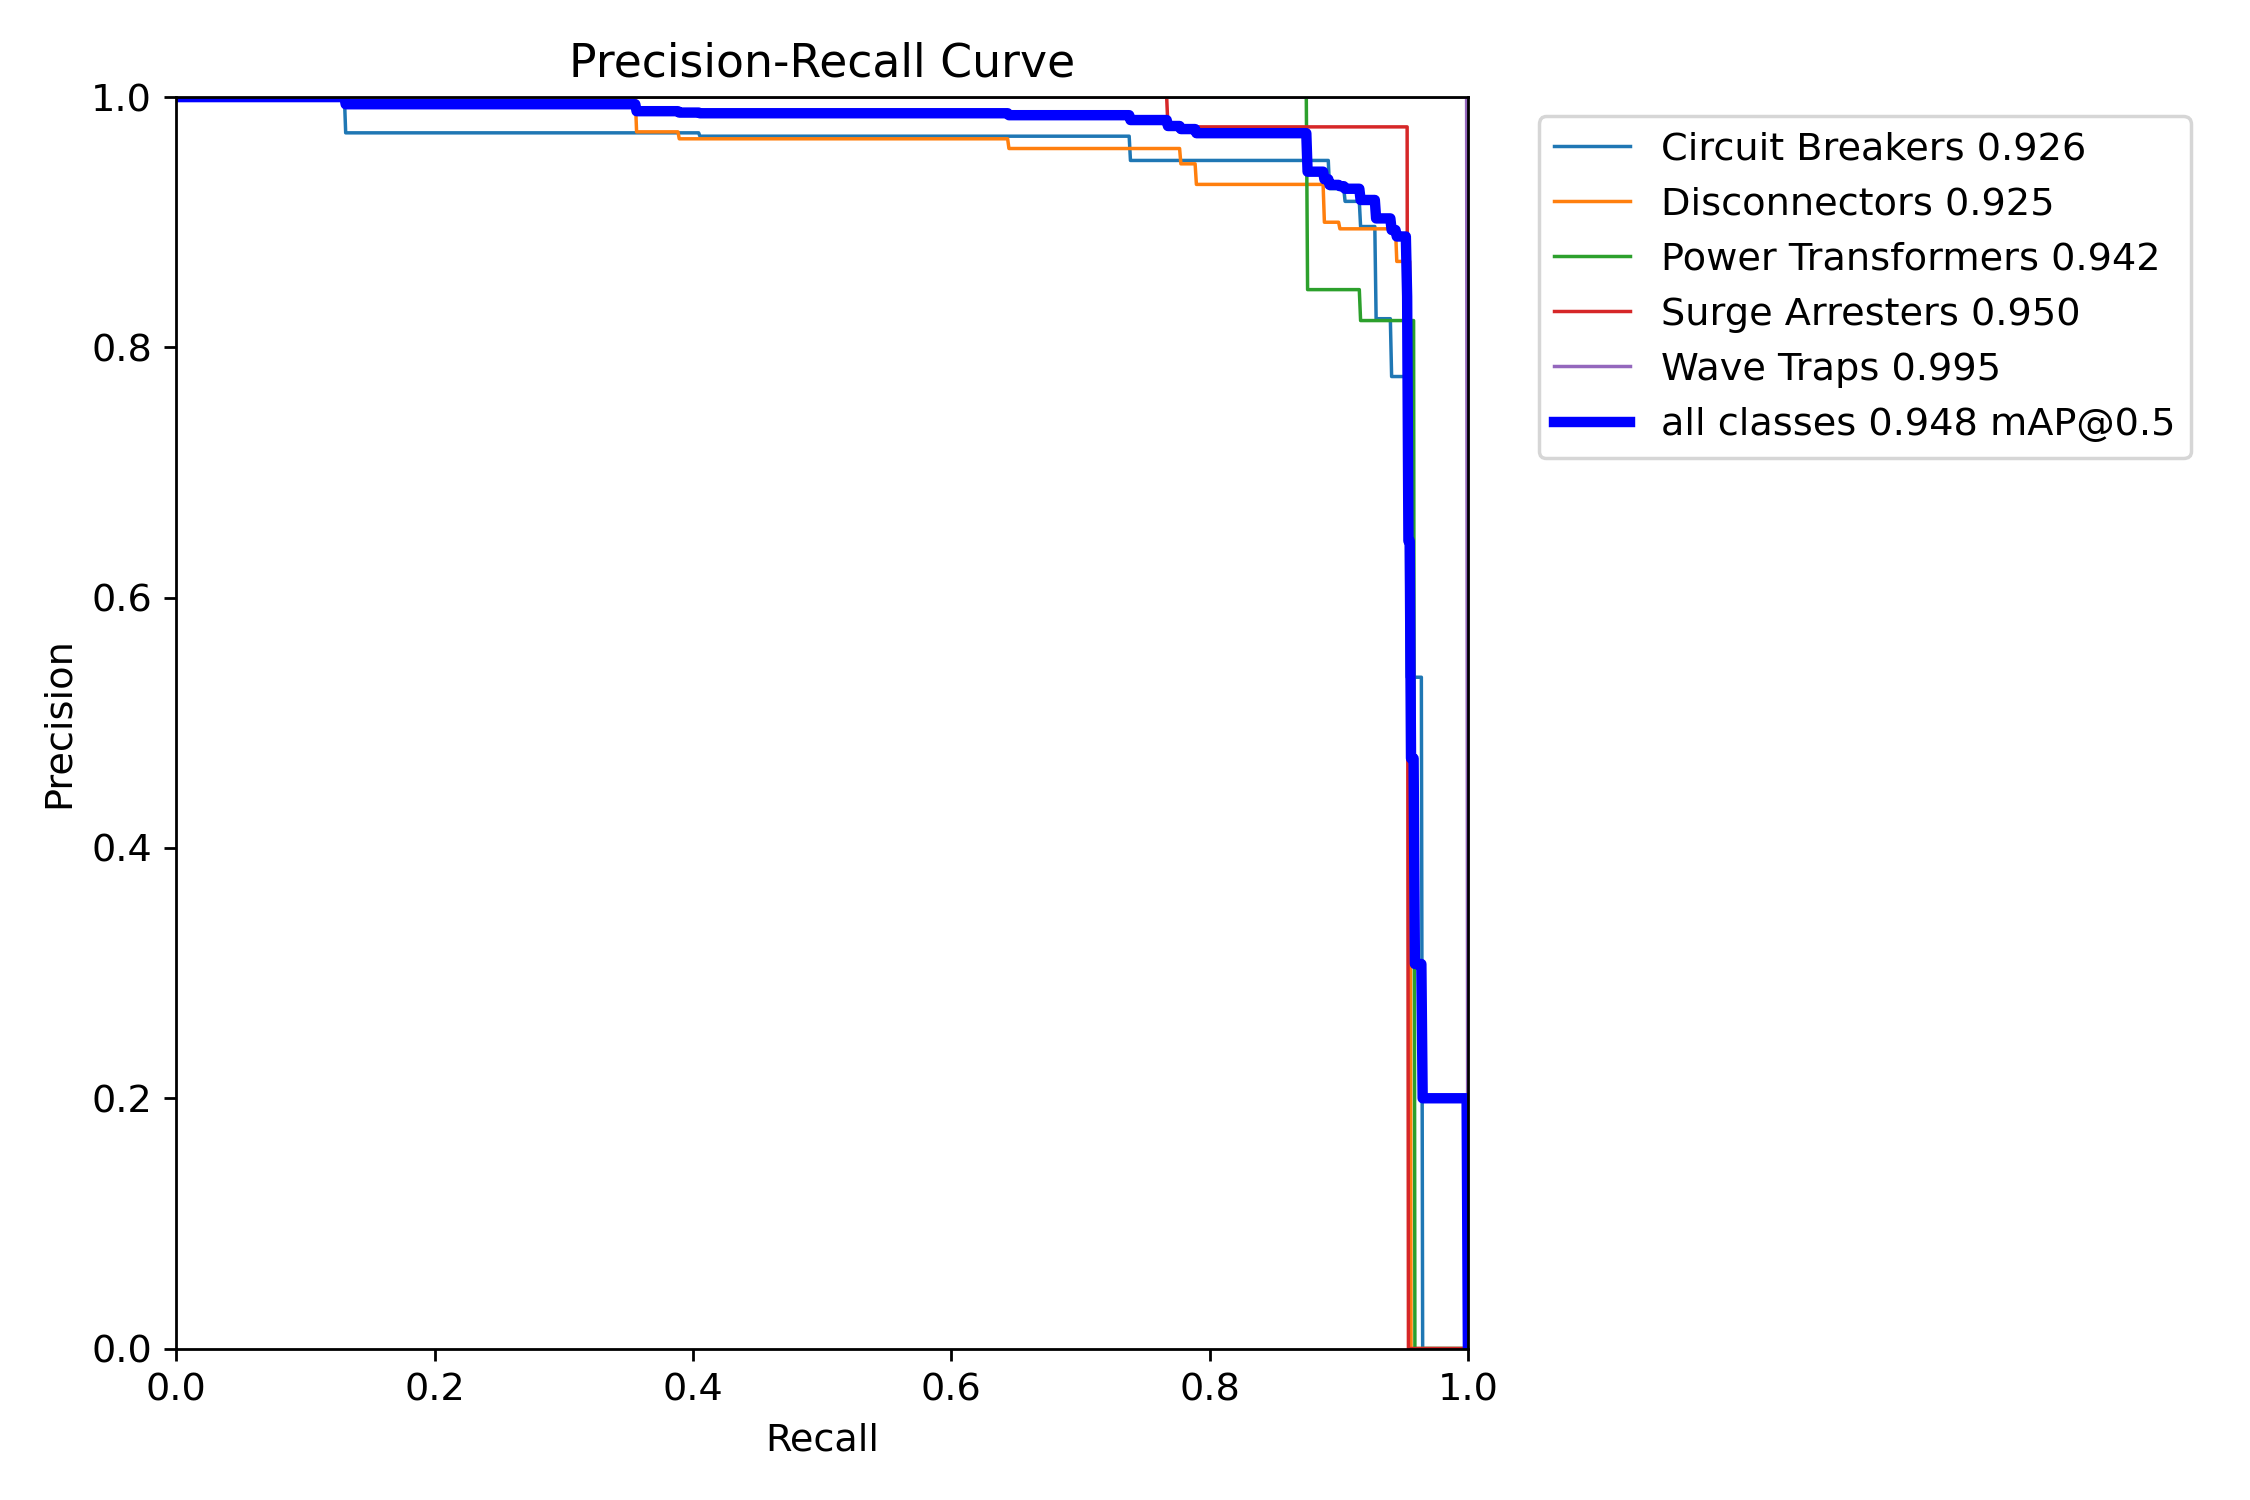

In [ ]:
latest_val_folder= max(glob.glob('/content/drive/MyDrive/YOLO_Equipment_project/Ablation_results/metrics/runs/detect/val*'))
charts = ['confusion_matrix_normalized.png','BoxF1_curve.png','BoxPR_curve.png']
for chart_name in charts:
   chart_path = f"{latest_val_folder}/{chart_name}"
   display(IPythonImage(filename = chart_path))

In [ ]:
#loading the trained model
MODEL_PATH= '/content/drive/MyDrive/YOLO_Equipment_project/Training_results/weights/best.pt'
model=YOLO(MODEL_PATH)
TICKET_DIR= '/content/drive/MyDrive/YOLO_Equipment_project/maintenance_tickets'
os.makedirs(TICKET_DIR,exist_ok=True)

In [ ]:
#defining the core severity engine
import cv2
import numpy as np
def analyze_thermal_severity(crroped_img):
  gray = cv2.cvtColor(crroped_img,cv2.COLOR_BGR2GRAY)
  I_ambient = np.mean(gray)
  if I_ambient==0 : I_ambient=1
  blurred = cv2.GaussianBlur(gray, (3, 3), 0)
  _, I_max, _, max_loc = cv2.minMaxLoc(blurred)

  severity_index = I_max / I_ambient

  urgency = "NORMAL"
  if severity_index >= 1.95: urgency = "CRITICAL"
  elif severity_index >= 1.65: urgency = "MEDIUM"
  elif severity_index >= 1.30: urgency = "LOW"

  return severity_index, urgency, max_loc


In [ ]:
from datetime import datetime
def generate_ticket(class_name, s_index, urgency, box, hotspot_loc, img_name):
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    ticket_id = f"TICK-{timestamp}-{class_name[:3].upper()}"
    filepath = os.path.join(TICKET_DIR, f"{ticket_id}.txt")

    content = f"""==================================================
SUBSTATION AUTOMATION SYSTEM - WORK TICKET
==================================================
TICKET ID          : {ticket_id}
GENERATED TIMESTAMP: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
SOURCE IMAGE FILE  : {img_name}
URGENCY LEVEL      : {urgency}
--------------------------------------------------
DIAGNOSTIC METRICS:
Target Asset Class : {class_name}
Severity Index (S) : {s_index:.4f}
YOLO Spatial Bounds: {box}
Relative Hotspot Coordinates: {hotspot_loc}
--------------------------------------------------
AUTOMATED EMERGENCY ACTION PLAN:
"""
    if urgency == "CRITICAL":
        content += " CRITICAL FAULT: Imminent hardware breakdown detected. Dispatch emergency crews immediately to isolate the component from the grid.\n"
    elif urgency == "MEDIUM":
        content += " ELEVATED STRESS: High contact resistance suspected. Schedule field diagnostics within 48 operational hours.\n"
    elif urgency == "LOW":
        content += " MINOR ANOMALY: Early thermal signature detected. Log to history tracking database for routine drone inspection inspection loops.\n"

    content += "=================================================="

    with open(filepath, "w") as f:
        f.write(content)
    print(f" [{urgency}] Ticket compiled successfully -> {filepath}")

In [ ]:
def run_pipeline(image_path):
    original_image = cv2.imread(image_path)
    img_name = os.path.basename(image_path)

    results = model(image_path, verbose=False)[0]

    detections_found = len(results.boxes)

    for box in results.boxes:
        xmin, ymin,xmax,ymax = map(int, box.xyxy[0].cpu().numpy())

        cls_id = int(box.cls[0].cpu().numpy())
        class_name = model.names[cls_id]

        cropped_asset= original_image[ymin:ymax, xmin:xmax]

        if cropped_asset.size== 0: continue

        s_index, urgency, hotspot_loc = analyze_thermal_severity(cropped_asset)

        if urgency != "NORMAL":
            generate_ticket(class_name,s_index, urgency,[xmin, ymin, xmax, ymax], hotspot_loc, img_name)
        else:
            print(f" {class_name} evaluated: Running within safe operating thresholds (S = {s_index:.2f}).")

In [ ]:
sample_images = glob.glob('/content/drive/MyDrive/YOLO_Equipment_project/Dataset_model1/test/images/*.jpg')

for img_path in sample_images:
    run_pipeline(img_path)

print("\n All images have been audited! Check your 'maintenance_tickets' folder.")

 [CRITICAL] Ticket compiled successfully -> /content/drive/MyDrive/YOLO_Equipment_project/maintenance_tickets/TICK-2026-06-06_07-26-27-POW.txt
 [MEDIUM] Ticket compiled successfully -> /content/drive/MyDrive/YOLO_Equipment_project/maintenance_tickets/TICK-2026-06-06_07-26-28-POW.txt
 [MEDIUM] Ticket compiled successfully -> /content/drive/MyDrive/YOLO_Equipment_project/maintenance_tickets/TICK-2026-06-06_07-26-28-POW.txt
 [MEDIUM] Ticket compiled successfully -> /content/drive/MyDrive/YOLO_Equipment_project/maintenance_tickets/TICK-2026-06-06_07-26-28-CIR.txt
 [MEDIUM] Ticket compiled successfully -> /content/drive/MyDrive/YOLO_Equipment_project/maintenance_tickets/TICK-2026-06-06_07-26-29-POW.txt
 [MEDIUM] Ticket compiled successfully -> /content/drive/MyDrive/YOLO_Equipment_project/maintenance_tickets/TICK-2026-06-06_07-26-29-POW.txt
 [MEDIUM] Ticket compiled successfully -> /content/drive/MyDrive/YOLO_Equipment_project/maintenance_tickets/TICK-2026-06-06_07-26-29-CIR.txt
 [LOW] Tick